# Essay for Assignment, Course MZ340V17, 2025

This is an essay covering the [assignment](https://martinfleischmann.net/sds/micro/course_information/assignment.html) for [Course MZ340V17, 2025](https://martinfleischmann.net/sds/micro/).

## Parts Covered

This covers Part one and Part two, choosing option two of Part two.

# Part one

In [1]:
import geopandas as gpd
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import esda
import matplotlib.pyplot as plt
from libpysal import graph
import tobler

## Derive Census Areas

The definition of census areas, `BarcelonaCiutat_SeccionsCensals.csv`, comes from ["Detail of administrative units of the city of Barcelona : districts, neighbourhoods, Interés area, basic statistical areas (AEB) and census areas"](https://opendata-ajuntament.barcelona.cat/data/en/dataset/20170706-districtes-barris/resource/e16856a7-b3c0-4c32-a468-cc190cbbf7a9).

From looking through a sample of the datasets on the [Open Data BCN ](https://opendata-ajuntament.barcelona.cat/data/en/dataset) website, many of them have a "Seccio_Censal" column which is a combination of the District Code and the Census Code ("Seccio_Censal"), and so we use this definition here.

In [2]:
from shapely import from_wkt

def combine_districts_and_census_areas(df, district_column='codi_districte', census_column='codi_seccio_censal'):
    """Combines districts and census areas into a single column, `Seccio_Censal`."""
    df["Seccio_Censal"] = (
        (df[district_column] * 1000 ) + df[census_column]
    )

GLOBAL_CRS = "EPSG:4326"
BARCELONA_CRS = "EPSG:25831"

def barcelona_census_areas(url="BarcelonaCiutat_SeccionsCensals.csv"):
    """This loads the census areas as defined in a CSV file, and returns a 
    GDF with a single `Seccio_Censal` column and associated geometry.

    The geometry is in a local Barcelona Projected CRS to make later area-related operations more correct.
    
    The `Seccio_Censal` column is the combination of the `codi_districte` and `codi_seccio_censal`.
    """
    df = pd.read_csv(url)
    combine_districts_and_census_areas(df)
    
    df["geometry"] = df["geometria_wgs84"].apply(from_wkt)
    df = df[["Seccio_Censal","geometry"]]
    
    assert df["Seccio_Censal"].is_unique
    df.set_index("Seccio_Censal")
    
    geographic_gdf = gpd.GeoDataFrame(df,geometry="geometry",crs=GLOBAL_CRS)
    projected_gdf = geographic_gdf.to_crs(BARCELONA_CRS)
    
    return projected_gdf

In [3]:
census_areas_gdf = barcelona_census_areas()

In [4]:
census_areas_gdf.head(2)

,Seccio_Censal,geometry
0,1001,"POLYGON ((431076.902 4581077.309, 431058.164 4..."
1,1002,"POLYGON ((431023.545 4581164.326, 430990.55 45..."


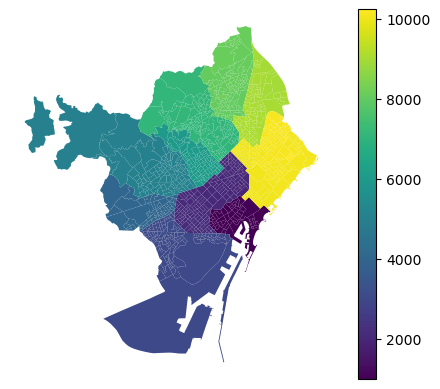

In [5]:
ax = census_areas_gdf.plot("Seccio_Censal", legend=True)
ax.set_axis_off()

## Choosing Socio-economic variables

There are many variables we could choose from. For simplicity we choose population and income to give both social and economic coverage:
* population is from ["Population of Barcelona according to the Municipal Register of Inhabitants on January 1 of each year"](https://opendata-ajuntament.barcelona.cat/data/en/dataset/pad_mdbas/resource/eb82adf2-a7b0-40e6-9624-b4b9eff23018)
* income is from ["Average gross taxable income per person (€) in the city of Barcelona based on Atlas de distribución de la renta de los hogares of Instituto Nacional de Estadística (INE)"](https://opendata-ajuntament.barcelona.cat/data/en/dataset/atles-renda-bruta-per-persona/resource/e6cabd96-68d6-451b-bc9f-c2a381d733e6)


In [6]:
def load_population_dataset(year):
    """Load population of Barcelona for a particular year; index is by `Seccio_Censal`.
    
    It is assumed data has been downloaded locally in a CSV prefixed by year.
    """
    df = pd.read_csv(f"{year}_pad_mdbas.csv")
    df["population"] = df["Valor"].astype(float)
    df = df[["population","Seccio_Censal"]]
    df.set_index("Seccio_Censal")
    return df

def load_income_dataset(year):
    """Load income of Barcelona for a particular year; index is by `Seccio_Censal`.

    It is assumed data has been downloaded locally in a CSV prefixed by year.
    """
    df = pd.read_csv(f"{year}_atles_renda_bruta_persona.csv")
    df["income"] = df["Import_Renda_Bruta_€"].astype(float)
    combine_districts_and_census_areas(df, district_column='Codi_Districte',census_column='Seccio_Censal')
    
    df = df[["income","Seccio_Censal"]]
    df.set_index("Seccio_Censal")
    return df

We choose a shared year that is the latest year both of the datasets are available.

In [7]:
shared_year=2023

population_df = load_population_dataset(shared_year)
population_df.head(2)

,population,Seccio_Censal
0,1246.0,1001
1,1238.0,1002


In [8]:
income_df = load_income_dataset(shared_year)
income_df.head(2)

,income,Seccio_Censal
0,17113.0,1001
1,13081.0,1002


## Merge with Census Areas

We can now merge these into the census areas to produce one GeoDataFrame for our analysis

In [12]:
def merge_in_dataframes(gdf, dfs):
    """Merge multiple DataFrames into a GeoDataFrame, based on index."""
    merged_gdf = gdf
    for df in dfs:
        merged_gdf = merged_gdf.merge(df)
    return merged_gdf

In [37]:
barcelona_gdf = merge_in_dataframes(census_areas_gdf, dfs=[population_df,income_df])
barcelona_gdf.head(2)

,Seccio_Censal,geometry,population,income
0,1001,"POLYGON ((431076.902 4581077.309, 431058.164 4...",1246.0,17113.0
1,1002,"POLYGON ((431023.545 4581164.326, 430990.55 45...",1238.0,13081.0


## Analysis

If we examine the chloropleths of each variable by eye we see a couple of things:
* for population, there appear to be a small number of areas with a lot of people, but apart from that there aren't many clear patterns
* for income, we see a few hotspots, particularly on the left-hand side, in an approximate "V" shape

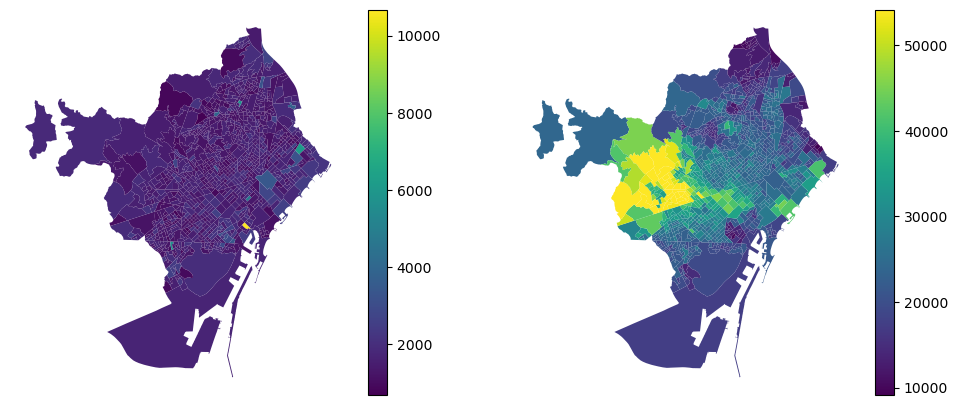

In [14]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
barcelona_gdf.plot("population", ax=axs[0], legend=True)
barcelona_gdf.plot("income", ax=axs[1], legend=True)
for ax in axs:
    ax.set_axis_off()
plt.show()

## Moran's I

To get a more rigorous idea of structure, we will first apply Moran I's at Global level. For each area, this takes a value of a variable in an area and compares it against the spatially-lagged value for the neighhourhood (contiguity) of that area.

In our definition here, because we are using the row-standardized contiguity for a census area, we end up with the spatially-lagged average population or income of each census area.


In [15]:
def std_dev(df, column, std_column=None):
    std_df = df.copy(deep=True)
    if std_column is None:
        std_column = f"{column}_std"
    
    std_df[std_column] = (
        std_df[column] - std_df[column].mean()
    ) / std_df[column].std()

    return std_df
    
def build_averaging_queen_contiguity(gdf):
    """build a Queen contiguity that is transformed to support averaging across nieghbours"""
    contiguity = graph.Graph.build_contiguity(gdf, rook=False)
    contiguity_r = contiguity.transform("r")

    return contiguity_r

def moran_global(gdf, column, crit_value=0.05):
    """Does a Global Spatial analysis using Moran's I for this dataset, and returns a plot 
    illustrating what is happening internally.
    """
 
    contiguity_r = build_averaging_queen_contiguity(gdf)
    
    # get ESDA to do the actual analysis
    moran = esda.Moran(gdf[column], contiguity_r)
    print(f"I: {moran.I}, P_sim: {moran.p_sim}, <{crit_value}?: {moran.p_sim < crit_value}")

    # redo the analysis as a visualisation
    std_column = f"{column}_std"
    lag_column = f"{column}_std_lag"
    std_gdf = std_dev(gdf, column, std_column=std_column)
    std_gdf[lag_column] = contiguity_r.lag(std_gdf[std_column])

    f, ax = plt.subplots(1, figsize=(6, 6))
    sns.regplot(
        x=std_column,
        y=lag_column,
        data=std_gdf,
        marker=".",
        scatter_kws={"alpha": 0.2},
        line_kws=dict(color="lightcoral")
    )
    ax.set_aspect('equal')
    plt.axvline(0, c="black", alpha=0.5)
    plt.axhline(0, c="black", alpha=0.5)

I: 0.09308043377892011, P_sim: 0.001, <0.05?: True


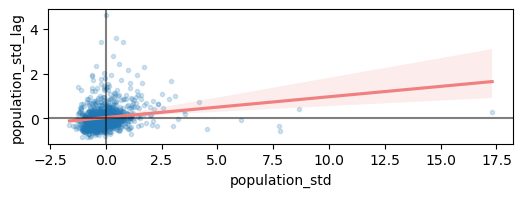

In [16]:
moran_global(barcelona_gdf, "population")

I: 0.8676035793980652, P_sim: 0.001, <0.05?: True


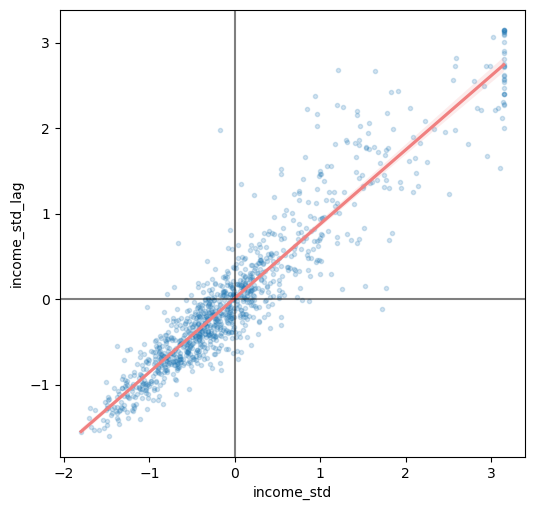

In [17]:
moran_global(barcelona_gdf, "income")

For both of these, because `P_sim` is less than 0.05 (5%), we can discount the null hypothesis that this correlation is random i.e. this is a real effect.

The value of Moran's I is greater for income than for population, which is consistent with our previous intuition: income is more spatially-correlated than population.

Note that I is particularly low for income, possibly caused by the large outlier, and the graph overall looks quite skewed. We shall aim to address some of this later with the grid.

## LISA (using Moran Local)

So, we have confidence that there are clusters, but we are also interested in what this looks on the actual map. For this we will use a LISA (Local Indicator of Spatial autocorrelation): Moran Local.

In [18]:
def moran_local_clusters(gdf, column, crit_value):
    """Does a Local Spatial analysis using Moran Local for this dataset, and returns the clusters."""

    contiguity_r = build_averaging_queen_contiguity(gdf)
    
    lisa_gdf = gdf.copy(deep=True)
    lisa = esda.Moran_Local(lisa_gdf[column], contiguity_r)

    lisa_gdf['cluster'] = lisa.get_cluster_labels(crit_value=crit_value)
    return lisa, lisa_gdf

In [19]:
crit_value=0.05
barcelona_population_lisa, barcelona_population_clusters_gdf = moran_local_clusters(
    barcelona_gdf, "population", crit_value)
barcelona_income_lisa, barcelona_income_clusters_gdf = moran_local_clusters(
    barcelona_gdf, "income", crit_value)

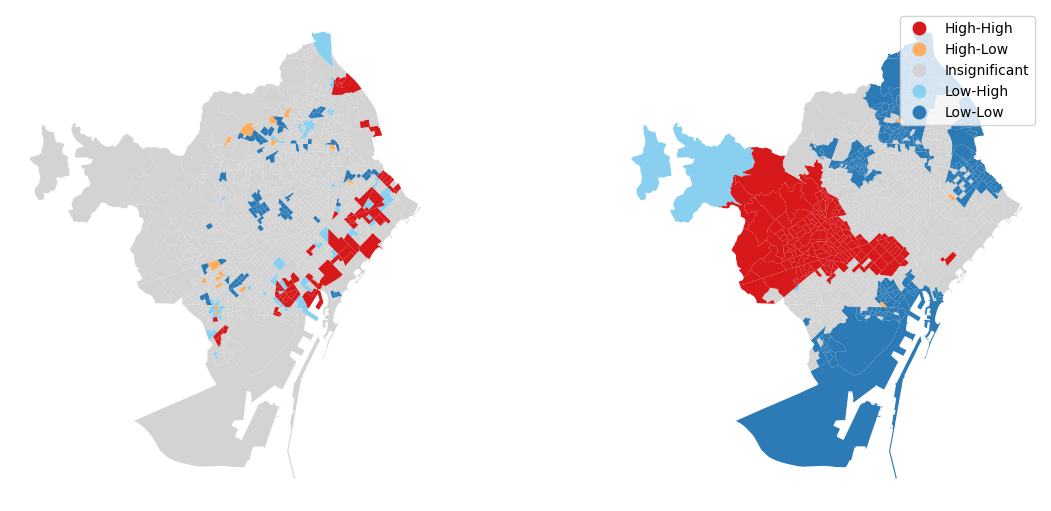

In [20]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5), layout="constrained")
barcelona_population_lisa.plot(
    barcelona_population_clusters_gdf,
    crit_value=crit_value,
    ax=axs[0],
    legend=False
)
barcelona_income_lisa.plot(
    barcelona_income_clusters_gdf,
    crit_value=crit_value,
    ax=axs[1],
    legend=True
)
for ax in axs:
    ax.set_axis_off()
plt.show()

From this we can see that:
* for population, the largest clusters are of high-high population areas, near the center of barcelona and on the coastline, with the other cluster types less present
* for income, there is a mix of high-high (including the V-shape we saw previously), with low-low areas on north and south. There are also a couple of areas on the outskirts at north-west that are low-high

## Controlling for size

We saw in the last section that we were getting some areas that were large and appearing in clusters. This can be misleading as the larger areas have a greater chance of being contiguous to other areas, which can skew the results. We also some weird results for Moran's I on income.

To gaurd against this we will repeat our analysis using a grid of areas where each area has approximately the same size. We will use [H3](https://h3geo.org) here which can still vary in size over different areas of whole earth (so would be invalid for comparison across cities, for example), but does not have meaningful variance over barcelona itself.

In [31]:
def build_safe_grid(gdf, resolution):
    """Builds a safe H3 grid, where safe means it has no isolates.

    Some later operations don't work if we have isolates (areas with no nieghbours), so we exclude them here.
    """
    initial_grid_gdf = tobler.util.h3fy(gdf.to_crs(GLOBAL_CRS), resolution=resolution)
    
    # build a Queen contiguity and use it solely to exclude the isolates from the grid
    contiguity = graph.Graph.build_contiguity(initial_grid_gdf, rook=False)
    isolates = contiguity.isolates
    filtered_grid_gdf = initial_grid_gdf[~initial_grid_gdf.index.isin(isolates)]
    
    return filtered_grid_gdf.to_crs(BARCELONA_CRS)

In [29]:
barcelona_grid_gdf = build_safe_grid(barcelona_gdf, resolution=9)
barcelona_grid_gdf.head(2)

,geometry
hex_id,
893944600c7ffff,"POLYGON ((427196.023 4583924.062, 427351.374 4..."
8939446352bffff,"POLYGON ((423400.197 4586604.058, 423374.683 4..."


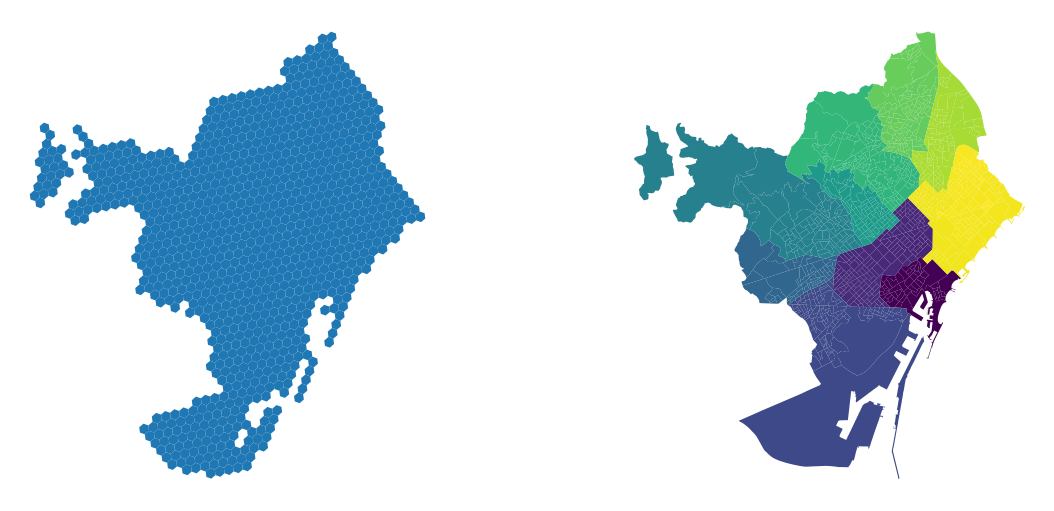

In [30]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5), layout="constrained")
barcelona_grid_gdf.plot(ax=axs[0])
census_areas_gdf.plot("Seccio_Censal", ax=axs[1])
for ax in axs:
    ax.set_axis_off()
plt.show()

## Interpolation

We need to interpolate our variables from the original census areas onto the grid, based on the area of overlap. We choose:
* population as an extensive variable as it was the sum over the census area, and so needs to be divided across grid areas, and
* income as an intensive variable, as it's actually average income, and so needs to be assumed the same across all overlapping areas. however, grid areas will stil be apportioned different incomes based on what area of overlap they have.

In [46]:
barcelona_interpolated_gdf = tobler.area_weighted.area_interpolate(
    source_df=barcelona_gdf, 
    target_df=barcelona_grid_gdf,
    extensive_variables=["population"],
    intensive_variables=["income"]
)

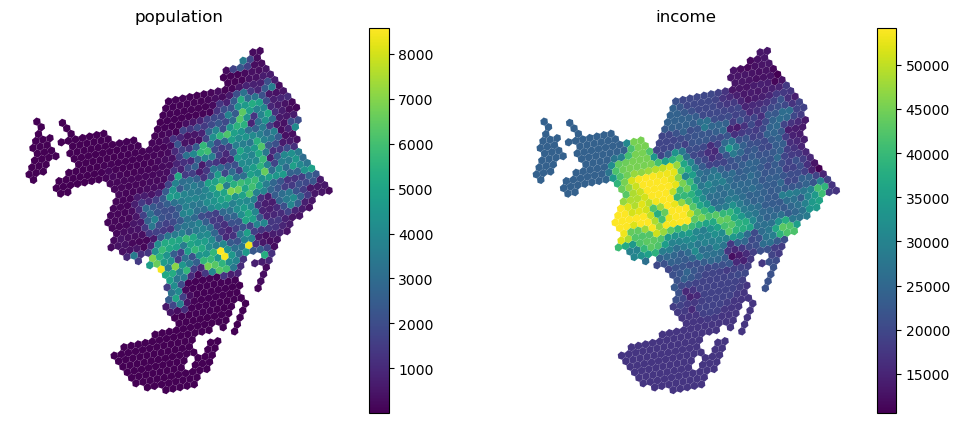

In [49]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
barcelona_interpolated_gdf.plot("population", ax=axs[0], legend=True)
barcelona_interpolated_gdf.plot("income", ax=axs[1], legend=True)
axs[0].set_title(f"population")
axs[1].set_title(f"income")
for ax in axs:
    ax.set_axis_off()
plt.show()

### Moran's I

I: 0.8063764552637569, P_sim: 0.001, <0.05?: True


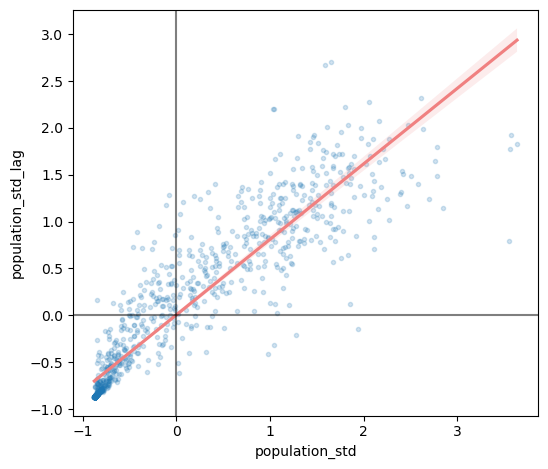

In [35]:
moran_global(barcelona_interpolated_gdf, "population")

I: 0.9403212329834736, P_sim: 0.001, <0.05?: True


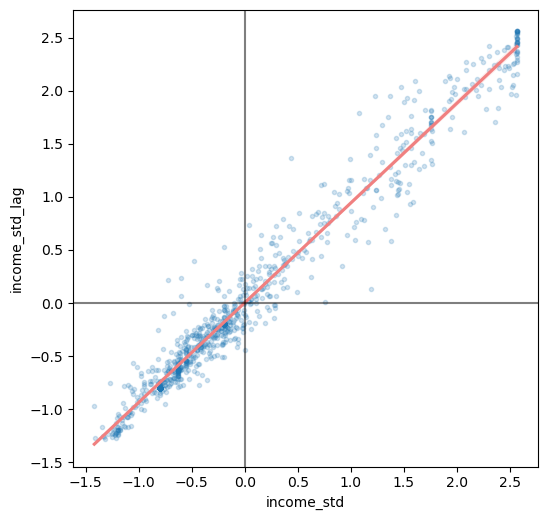

In [36]:
moran_global(barcelona_interpolated_gdf, "income")

Again, we see both are significant, and Moran's I is greater for population than income. However, we also see the graph for income is far cleaner, with less outlier, and a far higher valuen of Moran's I.

### LISA

In [38]:
crit_value=0.05
barcelona_interpolated_population_lisa, barcelona_interpolated_population_clusters_gdf = moran_local_clusters(
    barcelona_interpolated_gdf, "population", crit_value)
barcelona_interpolated_income_lisa, barcelona_interpolated_income_clusters_gdf = moran_local_clusters(
    barcelona_interpolated_gdf, "income", crit_value)

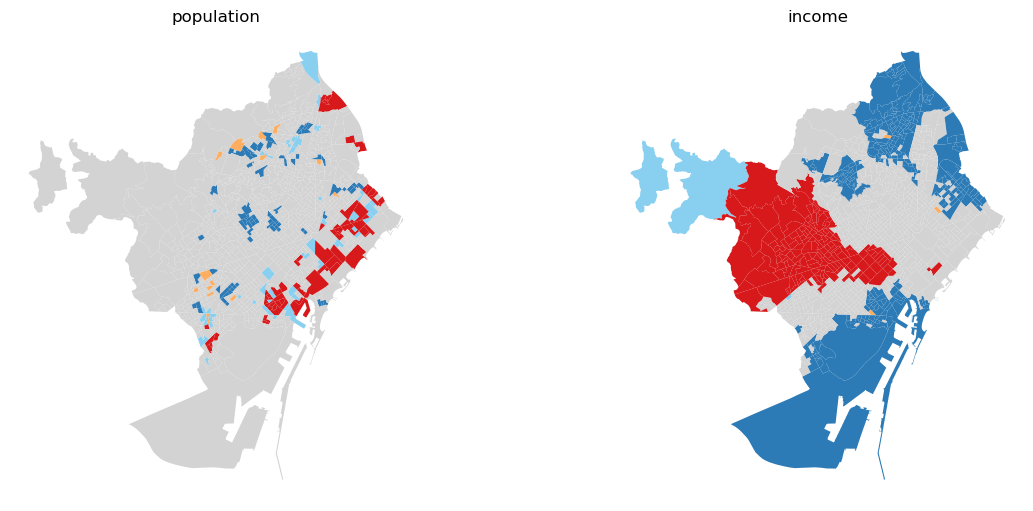

In [51]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5), layout="constrained")
axs = axs.flatten()
axs[0].set_title(f"population")
axs[1].set_title(f"income")
barcelona_population_lisa.plot(
    barcelona_population_clusters_gdf,
    crit_value=crit_value,
    ax=axs[0],
    legend=False
)
barcelona_income_lisa.plot(
    barcelona_income_clusters_gdf,
    crit_value=crit_value,
    ax=axs[1],
    legend=False
)
for ax in axs:
    ax.set_axis_off()
plt.show()

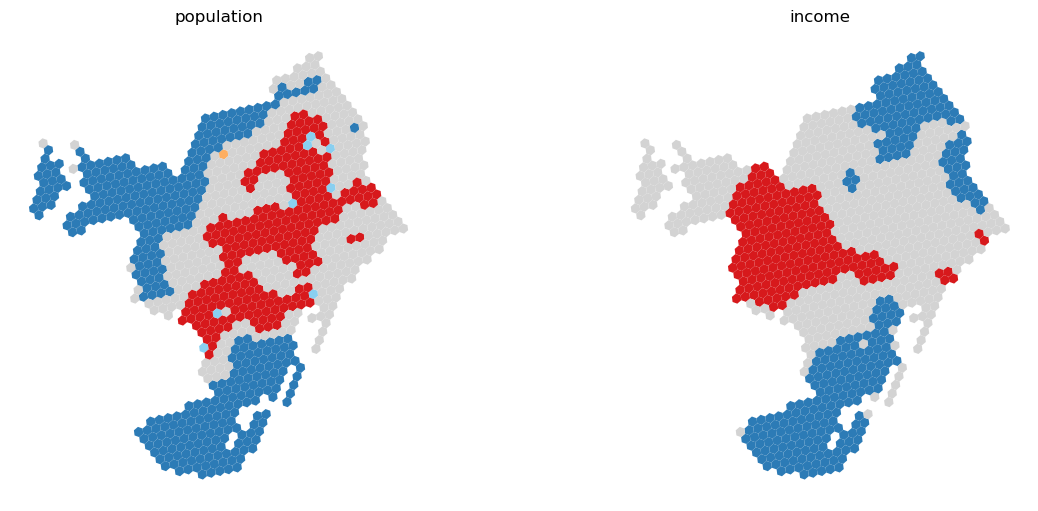

In [53]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5), layout="constrained")
axs = axs.flatten()
axs[0].set_title(f"population")
axs[1].set_title(f"income")
barcelona_interpolated_population_lisa.plot(
    barcelona_interpolated_population_clusters_gdf,
    crit_value=crit_value,
    ax=axs[0],
    legend=False
)
barcelona_interpolated_income_lisa.plot(
    barcelona_interpolated_income_clusters_gdf,
    crit_value=crit_value,
    ax=axs[1],
    legend=False
)
for ax in axs:
    ax.set_axis_off()
plt.show()

Comparing back against the original LISA results, we see that income is roughly the same as before, but with the low-high area at north-west gone.

For population, it's quite different, as the global Moran I plot also was. Given the original skewed distribution, and the knowledge that operations such as mean are easily skewed by outlier values, we decide to conclude this grid-based summary of clusters is more accurate.